# Landlab fundamentals: from a grid to a model

**Duration:** 2 hours 20 minutes, including a 10-minute break

This lesson is adapted from Ivy's `01-intro.ipynb`, `02-data.ipynb`,
`04-numerics.ipynb`, `05-components.ipynb`, and
`ESPIn_2026/01_a_simple_landlab_model.ipynb`.

By the end, you will be able to:

- create and inspect a raster grid;
- attach and visualize node fields;
- set boundary conditions;
- discover a component's field and parameter requirements;
- run `LinearDiffuser` in a time loop; and
- compare two model experiments.

Our reusable workflow is:

> question → grid → fields → boundaries → components → time loop → diagnostics

## 1. Meet the grid (20 minutes)

A Landlab **grid** is the spatial framework on which a model operates. It does
two related jobs:

1. It describes the geometry of the domain: where points are and how far apart
   they are.
2. It describes the topology: which points and areas are connected to one
   another.

The grid is therefore more than a picture or a two-dimensional NumPy array. It
is a Python object containing coordinates, connectivity, boundary status, and
any model data we attach to it.

Landlab divides a grid into several types of **element**. The three most useful
for this workshop are:

| Element | Meaning | Typical quantity |
| --- | --- | --- |
| **Node** | A point with an $x,y$ coordinate | elevation, water depth |
| **Link** | A directed connection between two neighboring nodes | gradient, flux |
| **Cell** | The area surrounding an interior node | area-integrated storage |

A physical quantity belongs at the element where it makes numerical sense.
Elevation is a value at a point, so it is usually stored at nodes. A flux moves
between neighboring points, so it is usually stored on links.

`RasterModelGrid((4, 5), xy_spacing=(10, 5))` creates four rows and five
columns of nodes. The spacing tuple is `(x spacing, y spacing)`, so adjacent
columns are 10 units apart and adjacent rows are 5 units apart.

Although a raster is visually two-dimensional, Landlab stores the values for
each element in **flat, one-dimensional arrays**. Node 0 is followed by node 1,
then node 2, and so on. This common representation lets the same components
work with raster, hexagonal, and irregular grids instead of assuming that all
domains can be indexed as rows and columns.

shape: (4, 5)
spacing: (np.float64(5.0), np.float64(10.0))
number of nodes: 20
core nodes: [ 6  7  8 11 12 13]


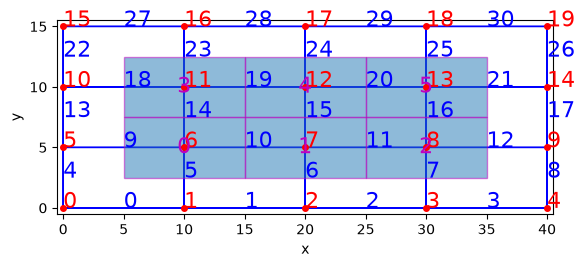

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from landlab import RasterModelGrid, imshow_grid
from landlab.plot.graph import plot_graph

small_grid = RasterModelGrid((4, 5), xy_spacing=(10.0, 5.0))
plot_graph(small_grid, at="node,link,cell")

print(f"shape: {small_grid.shape}")
print(f"spacing: {small_grid.spacing}")
print(f"number of nodes: {small_grid.number_of_nodes}")
print(f"core nodes: {small_grid.core_nodes}")

### What the grid-creation cell did

- The imports made NumPy, Matplotlib, the raster-grid class, Landlab's image
  plotter, and a topology plotter available. Importing them did not create a
  model.
- `small_grid` is an **instance** of `RasterModelGrid`. It now owns coordinates
  and connectivity for 20 nodes and the links and cells derived from them.
- `plot_graph` displayed topology. It did not add data to the grid or change
  it.
- `shape` and `spacing` describe the raster geometry. `number_of_nodes` and
  `core_nodes` are derived from that geometry and the current boundary status.

The word *core* has a numerical meaning: core nodes are the nodes at which
model state is normally allowed to evolve. Perimeter nodes begin as boundary
nodes. We will decide what kind of boundary each edge represents later.

### Predict, then inspect

Before running the next cell, use the graph and the grid dimensions to answer:

1. Which node is at `(x=20, y=5)`?
2. What shape do you expect `x_of_node` to have: `(4, 5)` or `(20,)`?
3. In which direction do node IDs increase?
4. Why are the perimeter nodes treated differently from the interior nodes?

`small_grid.nodes.reshape(small_grid.shape)` is used only to make the numbering
easy for a person to read. Reshaping this view does not change Landlab's
one-dimensional storage convention.

In [ ]:
print("node IDs:", small_grid.nodes.reshape(small_grid.shape), sep="\n")
print("x coordinates:", small_grid.x_of_node)
print("y coordinates:", small_grid.y_of_node)
print("coordinate-array shape:", small_grid.x_of_node.shape)

### Reading the coordinate arrays

`x_of_node[i]` and `y_of_node[i]` are the coordinates of node `i`. The same
index always refers to the same node across all node-sized arrays. For example,
if node 7 later has an elevation field, its elevation will be stored at index 7
of that field.

This index alignment is fundamental to Landlab:

> grid geometry at node `i` ↔ every at-node field value at index `i`

Landlab can therefore perform grid operations without storing an `(x, y,
value)` object for every point. The grid stores geometry once; each field only
stores its values.

> **Remember — grid shape counts nodes**
>
> A `(n_rows, n_columns)` `RasterModelGrid` counts node positions, not image
> pixels. Its physical width is `(n_columns - 1) * dx` and its height is
> `(n_rows - 1) * dy`. Changing the number or spacing of nodes changes the
> represented domain and may also change the numerical behavior.

## 2. Fields and boundaries (20 minutes)

### What is a field?

A **field** is an array of values registered with a grid at a named element
location. It combines three pieces of information:

- a meaningful name, such as `topographic__elevation`;
- a location, such as `node` or `link`; and
- one value for every element at that location.

Fields can be accessed through dictionary-like containers:

```python
grid.at_node["topographic__elevation"]
grid.at_link["sediment__volume_flux"]
```

An at-node field must contain exactly `grid.number_of_nodes` values; an at-link
field must contain exactly `grid.number_of_links` values. The location is part
of the meaning. A 625-value array is not enough information by itself—we also
need to know whether those values represent nodes, links, or something else.

Landlab field names commonly use the pattern `object__quantity`, with a double
underscore separating the two parts. Standard names are important because
components use them as a shared vocabulary. A component asking for
`topographic__elevation` can use a field created by you, read from a DEM, or
produced by another component.

The grid owns the field, while a normal Python variable can refer to the same
array. In the next cell, `z` and
`grid.at_node["topographic__elevation"]` are two references to the same data.
Changing `z` changes the field on the grid; no copy is made unless we explicitly
request one with `.copy()`.

In [ ]:
grid = RasterModelGrid((25, 25), xy_spacing=10.0)
z = grid.add_zeros("topographic__elevation", at="node")

# Start with a gently sloping surface.
z[:] = 0.01 * grid.y_of_node

# Add a Gaussian mound using distances from the center node.
center_node = grid.grid_coords_to_node_id(12, 12)
distance = np.hypot(
    grid.x_of_node - grid.x_of_node[center_node],
    grid.y_of_node - grid.y_of_node[center_node],
)
z += 50.0 * np.exp(-(distance**2) / (2.0 * 25.0**2))

print("node fields:", list(grid.at_node))
print("field shape:", z.shape)
imshow_grid(grid, "topographic__elevation", cmap="terrain", colorbar_label="Elevation (m)")

### What the field-creation cell did

1. A new 25-by-25 grid was created. This grid is independent of `small_grid`.
2. `add_zeros(..., at="node")` allocated 625 zeros, registered that array as
   the grid's `topographic__elevation` field, and returned a reference called
   `z`.
3. `z[:] = ...` changed every value **in place**. The slice `[:]` matters: it
   preserves the registered array rather than replacing the variable with a
   different array.
4. NumPy calculated the distance from every node to the center at once. The
   Gaussian expression then added a smooth mound without a Python loop.
5. `imshow_grid` looked up or received node values and displayed them in their
   spatial positions. The underlying field remained one-dimensional.

You can verify the shared reference with:

```python
z is grid.at_node["topographic__elevation"]  # True
```

This shared-state design is how a component can modify a field and make the
result immediately available to your plotting code or to another component.

> **Watch out — names, views, and copies are different**
>
> `z = grid.at_node["topographic__elevation"]` does not copy the field: `z`
> and the grid refer to the same NumPy array. Another assignment such as
> `other = z` shares that object, and a basic slice such as `view = z[:]`
> shares its underlying memory. Only `independent = z.copy()` creates separate
> values.
>
> This also makes `z += 1` different from `z = z + 1`. The first modifies the
> attached field in place. The second creates a new array and makes `z` refer
> to it, while the grid continues to hold the original field. Use `is` and
> `np.shares_memory(...)` when you are unsure whether two names are connected.

> **Watch out — notebooks remember old state**
>
> Running a field-creation cell twice can produce a “field already exists”
> error, while running later cells out of order can silently reuse an old
> landscape. When results become confusing, use **Restart Kernel and Run All**.
> A model that only works in a particular click order is not reproducible.

### Boundary conditions

The edge of a computational grid needs a numerical rule. Without one, the
model would not know whether material may cross the edge or whether a value at
the edge must remain fixed.

For this lesson we use two node statuses:

- A **closed boundary** has no active connection across the boundary. For the
  diffusion example, this represents a no-flux edge: sediment cannot leave or
  enter there.
- A **fixed-value boundary** keeps its field value fixed while adjacent core
  nodes evolve. It can act as a source or sink needed to maintain that value.

Core nodes are the interior nodes where the component updates elevation.
Boundary status is stored in `grid.status_at_node`, while Landlab derives which
links are active from the statuses at their ends. Setting a boundary condition
changes these numerical statuses and connections; it does not automatically
change the elevation values.

Here the left and right edges are closed. The top and bottom edges remain
fixed-value boundaries. Before running the cell, predict where sediment can
leave the modeled domain and where it cannot.

In [ ]:
grid.set_closed_boundaries_at_grid_edges(
    right_is_closed=True,
    top_is_closed=False,
    left_is_closed=True,
    bottom_is_closed=False,
)

print("core nodes:", grid.number_of_core_nodes)
print("closed boundary nodes:", np.count_nonzero(grid.status_at_node == grid.BC_NODE_IS_CLOSED))
print("fixed-value boundary nodes:", np.count_nonzero(grid.status_at_node == grid.BC_NODE_IS_FIXED_VALUE))

### Reading the boundary-setting call

The keyword arguments make the edge ordering explicit. `True` means “make this
edge closed”; `False` means that edge is not closed and is set to the default
fixed-value status by this method.

The counts include corner nodes, which belong to two edges but receive one
final node status. For most modeling work you do not need to edit
`status_at_node` directly—use Landlab's boundary methods and inspect the result.

A boundary condition should follow the scientific question. “Closed” is not a
safer default, and “fixed” is not automatically more realistic. Ask what is
assumed to happen to mass or energy at each edge of the domain.

> **Scientific choice — boundaries are part of the hypothesis**
>
> Boundary conditions can influence much more than the outermost row of a small
> grid. Record them with the model parameters and, when possible, test whether
> the conclusion survives another scientifically defensible boundary setup.

### Pair exercise

Choose one change, predict its effect, make it, and rerun the plot:

- double the mound height;
- move the mound center;
- reverse the background slope; or
- close a different pair of boundaries.

Restore and rerun the supplied cells before continuing.

## 3. Components are contracts (15 minutes)

A Landlab **component** is a Python class that implements a process or
calculation. The grid and components have deliberately different roles:

- the **grid owns the domain and state fields**;
- a **component reads and updates particular fields** according to an
  algorithm; and
- your **model script controls setup, component order, parameters, and time**.

A component instance keeps a reference to its grid. It generally does not
return a new landscape after each step. Instead, it updates fields attached to
that grid in place.

The interface between a component and a grid is a **field contract**. Component
metadata tells us:

- which field names are inputs and outputs;
- whether each field belongs at nodes, links, or another element;
- the expected units and data type; and
- what the field represents.

Constructor arguments such as `linear_diffusivity` are parameters, not fields.
Parameters configure the process; fields hold spatially distributed model
state. Landlab reports expected units but does not generally convert your
numbers automatically, so the modeler must use one internally consistent unit
system.

In [ ]:
from landlab.components import LinearDiffuser

print("inputs:", LinearDiffuser.input_var_names)
print("outputs:", LinearDiffuser.output_var_names)
LinearDiffuser.var_help("topographic__elevation")

### Interpreting the component metadata

The same field may appear as both an input and an output. `LinearDiffuser`
reads the current `topographic__elevation`, calculates diffusive transport, and
then updates that elevation. This is an **in-place state update**, not a
contradiction.

`var_help` adds the field's location, units, type, and definition. Check this
metadata before creating fields for an unfamiliar component. A correctly
spelled field at the wrong location is still the wrong input.

Metadata describes fields shared through the grid. The class docstring
describes constructor parameters and methods, which is why both sources of
documentation are useful.

> **Remember — metadata describes units; it does not convert them**
>
> Landlab cannot generally detect metres mixed with degrees, seconds mixed with
> years, or millimetres per hour mixed with metres per second. Check field
> locations and convert every quantity into one consistent unit system before
> running a component.

### Documentation challenge

Run `help(LinearDiffuser)` or place the cursor inside
`LinearDiffuser(...)` and press **Shift+Tab**. Find:

1. the required grid argument;
2. the parameter controlling diffusivity; and
3. the method that advances the component through time.

In [ ]:
help(LinearDiffuser)

## Break (10 minutes)

## 4. Run the first model (30 minutes)

At this point the grid contains geometry, boundary statuses, and an elevation
field, but nothing has evolved. Three more decisions turn that setup into a
model run:

1. **Instantiate the process.** `LinearDiffuser(grid, ...)` connects the
   algorithm to this particular grid and configures its diffusivity.
2. **Choose a timestep and duration.** A timestep is the amount of modeled time
   represented by one update, not the wall-clock time required to calculate it.
3. **Advance the component repeatedly.** Calling `run_one_step(dt)` once moves
   the state forward by `dt`; constructing the component alone does not.

The grid does not know whether our numbers mean meters, years, or seconds. With
elevation and spacing in meters and diffusivity in m²/year, the timestep must be
in years. Unit consistency is our responsibility.

The variable `z` still refers to the field on `grid`. We first make
`z_initial = z.copy()` because the component will mutate `z` in place. Without
the copy, “initial” and “final” would be two names for the same updated array.

In [ ]:
z_initial = z.copy()
diffuser = LinearDiffuser(grid, linear_diffusivity=0.02)

time_step = 10.0  # years
total_time = 10_000.0  # years
elapsed_time = 0.0

while elapsed_time < total_time:
    diffuser.run_one_step(time_step)
    elapsed_time += time_step

print(f"completed {elapsed_time:,.0f} years")

### Reading the model loop

- `diffuser` holds the algorithm, its parameter values, and a reference to
  `grid`.
- `time_step` controls the increment passed to each update.
- `total_time` controls how long the experiment represents.
- `elapsed_time` is bookkeeping performed by our script. It is not a field on
  the grid.
- Every `run_one_step` call reads the current elevation and updates the same
  `topographic__elevation` array. The next iteration therefore starts from the
  previous iteration's result.

This separation is useful: the same component can participate in many model
loops, and the modeler remains responsible for when and how often it runs.

> **Model check — running without an error is only the first test**
>
> A numerically successful result may still be physically implausible. Inspect
> value ranges, maps, boundary effects, conservation or budget quantities, and
> sensitivity to timestep or resolution before interpreting the result.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plt.sca(axes[0])
imshow_grid(grid, z_initial, cmap="terrain", colorbar_label="Elevation (m)")
axes[0].set_title("Initial")
plt.sca(axes[1])
imshow_grid(grid, z, cmap="terrain", colorbar_label="Elevation (m)")
axes[1].set_title("Final")
plt.sca(axes[2])
imshow_grid(grid, z - z_initial, cmap="RdBu", colorbar_label="Elevation change (m)")
axes[2].set_title("Change")
plt.tight_layout()

print(f"initial relief: {np.ptp(z_initial):.2f} m")
print(f"final relief:   {np.ptp(z):.2f} m")

### Why plot three views?

- The **initial map** records the starting condition.
- The **final map** shows the state after the requested duration.
- The **difference map** computes `final - initial`, making both erosion
  (negative change) and deposition (positive change) visible.

The two relief values are scalar diagnostics: maximum elevation minus minimum
elevation. A map shows *where* change occurred, while a scalar makes runs easy
to compare. Neither is sufficient for every scientific question, which is why
diagnostics should be chosen before interpreting an experiment.

### Interpret before continuing

- Where was material removed and where was it deposited?
- Did relief increase or decrease?
- How did the boundary conditions influence the edges?
- Which line would you change to represent a more diffusive landscape?

## 5. A controlled experiment (20 minutes)

A parameter value is scientifically meaningful only in comparison with a
baseline or observation. Here we compare two otherwise identical runs and vary
only diffusivity.

The function creates a **new grid and new elevation field on every call**. This
is important. Reusing the already evolved grid would make the second run start
from the first run's final topography, so the experiments would differ in both
diffusivity and initial condition.

Packaging setup, execution, and returned results in a function gives each run
the same recipe. The function returns the grid because plotting needs its
geometry, the initial array for comparison, and the final field reference.

In [ ]:
def run_mound_diffusion(diffusivity, total_time=10_000.0, time_step=10.0):
    experiment_grid = RasterModelGrid((25, 25), xy_spacing=10.0)
    elevation = experiment_grid.add_zeros("topographic__elevation", at="node")
    elevation[:] = 0.01 * experiment_grid.y_of_node

    center = experiment_grid.grid_coords_to_node_id(12, 12)
    distance = np.hypot(
        experiment_grid.x_of_node - experiment_grid.x_of_node[center],
        experiment_grid.y_of_node - experiment_grid.y_of_node[center],
    )
    elevation += 50.0 * np.exp(-(distance**2) / (2.0 * 25.0**2))
    experiment_grid.set_closed_boundaries_at_grid_edges(True, False, True, False)

    initial = elevation.copy()
    component = LinearDiffuser(experiment_grid, linear_diffusivity=diffusivity)
    for _ in range(int(total_time / time_step)):
        component.run_one_step(time_step)

    return experiment_grid, initial, elevation


slow_grid, slow_initial, slow_final = run_mound_diffusion(0.01)
fast_grid, fast_initial, fast_final = run_mound_diffusion(0.05)

print(f"D=0.01 final relief: {np.ptp(slow_final):.2f} m")
print(f"D=0.05 final relief: {np.ptp(fast_final):.2f} m")

### Interpreting the experiment

The dictionary-like field interface exists independently on `slow_grid` and
`fast_grid`; the two model states cannot accidentally overwrite one another.
Because duration, timestep, spacing, boundaries, and initial topography are
held constant, a difference between the outputs can be attributed to the
changed diffusivity within this model.

That is a model sensitivity result, not automatically evidence that either
diffusivity is correct for a real landscape. Calibration or validation would
require observations and an explicit comparison metric.

> **Fair comparison — start every run from independent state**
>
> A component mutates fields on its grid. Reusing that grid means continuing
> from an evolved landscape, not repeating the original experiment. Construct
> a fresh grid or restore an explicit `.copy()` of every initial state field.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.sca(axes[0])
imshow_grid(slow_grid, slow_final, cmap="terrain", colorbar_label="Elevation (m)")
axes[0].set_title("D = 0.01")
plt.sca(axes[1])
imshow_grid(fast_grid, fast_final, cmap="terrain", colorbar_label="Elevation (m)")
axes[1].set_title("D = 0.05")
plt.tight_layout()

### Pair experiment

1. Predict what changing one variable will do.
2. Change **one** of diffusivity, model duration, grid spacing, initial
   topography, or boundaries.
3. Compare against the supplied baseline.
4. Write one claim supported by a plot or relief value.

**Our prediction:**  
**What we changed:**  
**Evidence:**  
**Interpretation:**

## 6. From synthetic terrain to supplied data (15 minutes)

A synthetic surface lets us isolate concepts and predict qualitative behavior.
A digital elevation model (DEM) adds real spatial structure, but also adds
questions about file format, missing values, coordinate reference systems,
resolution, and computational cost.

`read_esri_ascii` performs two linked operations:

1. it builds a `RasterModelGrid` from the raster dimensions and cell size in
   the file header; and
2. it reads elevation values, flattens them in the ordering Landlab expects,
   and registers them as an at-node field using the supplied name.

It returns both the grid and a reference to the elevation field. As before,
`dem_z` and `dem_grid.at_node["topographic__elevation"]` refer to the same
underlying values.

In [ ]:
from pathlib import Path
from landlab.io import read_esri_ascii

dem_path = Path("../data/SRTMGL1_39.93_-105.33_40.0_-105.26.asc")
dem_grid, dem_z = read_esri_ascii(dem_path, name="topographic__elevation")

print(f"shape: {dem_grid.shape}")
print(f"spacing in source file: {dem_grid.spacing}")
print(f"elevation range: {dem_z.min():.1f} to {dem_z.max():.1f} m")
imshow_grid(dem_grid, "topographic__elevation", cmap="terrain", colorbar_label="Elevation (m)")

> **Data check — loading is not validation**
>
> Before using a DEM, inspect its coordinate reference system, orientation,
> spacing, elevation units, missing-data value, minimum and maximum, and map.
> A file can load successfully while still being unsuitable for the intended
> calculation.

### Coordinates and units matter

The file's horizontal coordinates are geographic longitude and latitude in
degrees, while elevation is in meters. A distance-based process such as
diffusion expects horizontal and vertical dimensions to form a consistent unit
system. Treating one degree as one meter would make slopes, fluxes, and
timescales physically meaningless.

For a real simulation, reproject the DEM into an appropriate projected
coordinate reference system and create a grid whose spacing is in meters. For
today's short project, use a supplied projected setup or a synthetic grid unless
reprojection is itself your learning goal.

Loading data is not the same as validating it. Before modeling, inspect its
shape, spacing, value range, orientation, missing-data values, and boundary
treatment.

## Exit check

Without looking back, explain to a partner:

1. how a grid differs from an elevation array;
2. what the name, location, and length of a field tell us;
3. why `z` changes when a component updates the grid;
4. how closed and fixed-value boundaries differ;
5. what a component needs before it can run; and
6. what advances model time.

Next, open one advanced track. Both tracks culminate in coupling components.

> **Before trusting or sharing a run**
>
> Record the Landlab version, grid type and spacing, initial fields, boundary
> conditions, component parameters and order, timestep, duration, and
> diagnostics. Then restart the kernel and run the notebook from top to bottom.

---

# Core lesson ends here

You now have everything required for either advanced track. The following
sections are optional extensions for participants who finish early or want to
see more of the numerical machinery. They are **not prerequisites** for the
advanced session and do not introduce component coupling.

## Optional A — Under the hood: build diffusion yourself (35–50 minutes)

`LinearDiffuser` hides a sequence of grid calculations. Here we reconstruct a
simple explicit diffusion model using links, gradients, fluxes, and flux
divergence.

The governing relationships are

$$q_s = -D \nabla z$$

and

$$\frac{\partial z}{\partial t} = -\nabla \cdot q_s,$$

where elevation $z$ is stored at nodes, its gradient and sediment flux $q_s$
are stored at links, and flux divergence is calculated back at nodes.

In [ ]:
def make_mound_grid(spacing=10.0):
    # Create the same reproducible initial condition for model comparisons.
    model_grid = RasterModelGrid((25, 25), xy_spacing=spacing)
    elevation = model_grid.add_zeros("topographic__elevation", at="node")
    elevation[:] = 0.01 * model_grid.y_of_node

    center = model_grid.grid_coords_to_node_id(12, 12)
    distance = np.hypot(
        model_grid.x_of_node - model_grid.x_of_node[center],
        model_grid.y_of_node - model_grid.y_of_node[center],
    )
    elevation += 50.0 * np.exp(-(distance**2) / (2.0 * 25.0**2))
    model_grid.set_closed_boundaries_at_grid_edges(True, False, True, False)
    return model_grid, elevation


manual_grid, manual_z = make_mound_grid()

print("first ten links as [tail node, head node]:")
print(manual_grid.nodes_at_link[:10])
print("first ten link lengths:")
print(manual_grid.length_of_link[:10])

### Follow one calculation across the grid

Before running the next cell, predict:

1. the length of the node-gradient array;
2. where the steepest positive and negative gradients occur; and
3. why the sediment flux has the opposite sign to the elevation gradient.

In [ ]:
diffusivity = 0.02
gradient_at_link = manual_grid.calc_grad_at_link(manual_z)
sediment_flux = manual_grid.zeros(at="link")
sediment_flux[manual_grid.active_links] = (
    -diffusivity * gradient_at_link[manual_grid.active_links]
)
rate_of_elevation_change = -manual_grid.calc_flux_div_at_node(sediment_flux)

print(f"node values: {manual_grid.number_of_nodes}")
print(f"link gradients: {gradient_at_link.size}")
print(f"maximum |gradient|: {np.abs(gradient_at_link).max():.3f}")
print(f"maximum |dz/dt|: {np.abs(rate_of_elevation_change).max():.5f}")

### Choose a stable timestep

For this explicit calculation, use a conservative Courant-style criterion:

$$\Delta t = 0.2

rac{\Delta x_{min}^2}{D}.$$

Try multiplying the stable timestep by 10 after completing the exercise. What
symptom tells you that a numerical result has become unstable?

> **Resolution has a computational cost**
>
> Smaller grid spacing creates more nodes and usually requires a smaller stable
> timestep for an explicit method. Doubling spatial resolution can therefore
> cost much more than twice as much. Check that conclusions are not artifacts
> of one convenient resolution or timestep.

In [ ]:
stable_time_step = 0.2 * manual_grid.length_of_link.min() ** 2 / diffusivity
total_time = 10_000.0
number_of_steps = int(np.ceil(total_time / stable_time_step))
actual_time_step = total_time / number_of_steps
manual_initial = manual_z.copy()

print(f"stable timestep: {stable_time_step:.1f} years")
print(f"using {number_of_steps} steps of {actual_time_step:.1f} years")

for _ in range(number_of_steps):
    gradient_at_link = manual_grid.calc_grad_at_link(manual_z)
    sediment_flux[manual_grid.active_links] = (
        -diffusivity * gradient_at_link[manual_grid.active_links]
    )
    rate_of_elevation_change = -manual_grid.calc_flux_div_at_node(sediment_flux)
    manual_z[manual_grid.core_nodes] += (
        rate_of_elevation_change[manual_grid.core_nodes] * actual_time_step
    )

In [ ]:
component_grid, component_z = make_mound_grid()
component = LinearDiffuser(component_grid, linear_diffusivity=diffusivity)
for _ in range(number_of_steps):
    component.run_one_step(actual_time_step)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plt.sca(axes[0])
imshow_grid(manual_grid, manual_z, cmap="terrain", colorbar_label="Elevation (m)")
axes[0].set_title("Manual grid operations")
plt.sca(axes[1])
imshow_grid(component_grid, component_z, cmap="terrain", colorbar_label="Elevation (m)")
axes[1].set_title("LinearDiffuser")
plt.sca(axes[2])
imshow_grid(
    manual_grid,
    manual_z - component_z,
    cmap="RdBu",
    colorbar_label="Elevation difference (m)",
)
axes[2].set_title("Manual minus component")
plt.tight_layout()

print(f"mean absolute difference: {np.mean(np.abs(manual_z - component_z)):.6f} m")

### Explain the data movement

Draw this sequence and annotate each quantity with its grid element:

> node elevation → link gradient → link flux → node divergence → node elevation

Then answer:

- Why do we update only `core_nodes`?
- Why do we calculate flux only on `active_links`?
- Which parts of this implementation does `LinearDiffuser` save you from
  maintaining?

## Optional B — Python challenge: parameter sweeps (20–30 minutes)

A final map can hide how quickly a system changed. Run several diffusivities,
record relief through time, and compare all trajectories. This exercise uses
ordinary Python functions, dictionaries, and plotting around one familiar
Landlab component.

In [ ]:
def relief_through_time(diffusivity, total_time=10_000.0, time_step=10.0):
    experiment_grid, elevation = make_mound_grid()
    diffuser = LinearDiffuser(experiment_grid, linear_diffusivity=diffusivity)

    times = [0.0]
    relief = [np.ptp(elevation)]
    elapsed = 0.0
    record_every = 50

    for step in range(1, int(total_time / time_step) + 1):
        diffuser.run_one_step(time_step)
        elapsed += time_step
        if step % record_every == 0:
            times.append(elapsed)
            relief.append(np.ptp(elevation))

    return np.asarray(times), np.asarray(relief)


diffusivities = [0.005, 0.01, 0.02, 0.05]
experiments = {
    diffusivity: relief_through_time(diffusivity)
    for diffusivity in diffusivities
}

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
for diffusivity, (times, relief) in experiments.items():
    ax.plot(times, relief, label=f"D = {diffusivity:g}")

ax.set(
    xlabel="Time (years)",
    ylabel="Topographic relief (m)",
    title="Diffusion reduces relief through time",
)
ax.legend()
ax.grid(alpha=0.25)

### Extension challenge

Choose one:

1. Find the first time at which each run falls below 25 m of relief.
2. Repeat the sweep with a different grid spacing. Use the stable-timestep
   relationship from Optional A to explain the computational effect.
3. Store final elevation as well as relief and create a comparison figure.

Write one claim that is supported by the trajectories rather than by the model
equations alone.

These exercises complete the optional material. Continue to one advanced track
for multi-component coupling and application-specific diagnostics.